# YOLO11s/m/l - CPU Inference und Accuracy Vergleich

Dieses Notebook vergleicht **YOLO11s**, **YOLO11m** und **YOLO11l** auf CPU
fuer mehrere Bildgroessen.

Fuer jede Kombination aus Modell und Bildgroesse werden erfasst:
- Inferenz Speed fuer
  - PyTorch normal
  - PyTorch mit `fuse()`
  - ONNX Runtime auf CPU (falls installiert)
- Genauigkeits Metriken (einmal pro Modell und Bildgroesse):
  - mAP50
  - mAP50-95
  - Precision (mp)
  - Recall (mr)

Bild Laden und Preprocessing finden ausserhalb der gemessenen Schleifen statt.
Die gemessene Zeit umfasst nur den eigentlichen Forward Pass.


In [8]:
from pathlib import Path

# Projekt Root anpassen
PROJECT_ROOT = Path("..").resolve()

# Modelle definieren: (Name, Pfad)
YOLO_MODELS = [
    ("YOLO11s", PROJECT_ROOT / "models" / "yolo11s_best.pt"),
    ("YOLO11m", PROJECT_ROOT / "models" / "yolo11m_best.pt"),
    ("YOLO11l", PROJECT_ROOT / "models" / "yolo11l_best.pt"),
]

# Ordner fuer ONNX Exporte
ONNX_DIR = PROJECT_ROOT / "models"

# Ultralytics data config fuer dein Schachdaten Set (fuer Genauigkeitsmessung)
YOLO_DATA_CONFIG = PROJECT_ROOT / "training_data" / "Automated-Chess-Move-Recognition-17-yolo" / "data.yaml"

# Optional: echtes Beispielbild (wird nur einmal geladen und vorverarbeitet)
# Wenn die Datei nicht existiert, wird ein Dummy Tensor verwendet.
SAMPLE_IMAGE = PROJECT_ROOT / "data" / "processed" / "game3_img_0003_warp.png"

# Bildgroessen fuer den Vergleich
IMAGE_SIZES = [640, 512, 416]

DEVICE = "cpu"

N_WARMUP = 10
N_ITERS = 50

print("Projekt Root:", PROJECT_ROOT)
print("Data config:", YOLO_DATA_CONFIG)
print("ONNX Ordner:", ONNX_DIR)
print("Sample Image exists:", SAMPLE_IMAGE.exists())

[(name, path, path.exists()) for name, path in YOLO_MODELS]


Projekt Root: C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition
Data config: C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\training_data\Automated-Chess-Move-Recognition-17-yolo\data.yaml
ONNX Ordner: C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\models
Sample Image exists: True


[('YOLO11s',
  WindowsPath('C:/Users/wolarz/OneDrive - adesso Group/Uni/chess-move-recognition/models/yolo11s_best.pt'),
  True),
 ('YOLO11m',
  WindowsPath('C:/Users/wolarz/OneDrive - adesso Group/Uni/chess-move-recognition/models/yolo11m_best.pt'),
  True),
 ('YOLO11l',
  WindowsPath('C:/Users/wolarz/OneDrive - adesso Group/Uni/chess-move-recognition/models/yolo11l_best.pt'),
  True)]

In [ ]:
%pip install ultralytics onnx onnxruntime pandas matplotlib pycocotools


In [3]:


import numpy as np
import pandas as pd
import torch

try:
    import onnxruntime as ort
    from onnxruntime.quantization import quantize_dynamic, QuantType

    HAS_ORT = True
except Exception:
    HAS_ORT = False

print("Torch device:", DEVICE)
print("ONNX Runtime verfuegbar:", HAS_ORT)


Torch device: cpu
ONNX Runtime verfuegbar: True


In [11]:
# Hilfsfunktionen fuer Eingaben


def make_input_tensor(image_size: int, device: str) -> torch.Tensor:
    """Erzeuge einen Eingabe Tensor (1,3,H,W).
    Wenn SAMPLE_IMAGE gesetzt und vorhanden ist, wird dieses Bild
    einmal geladen und vorverarbeitet. Sonst ein Dummy Tensor.
    Laden und Resize passieren ausserhalb der Mess Schleife.
    """
    if SAMPLE_IMAGE is not None and Path(SAMPLE_IMAGE).exists():
        import cv2

        img = cv2.imread(str(SAMPLE_IMAGE))
        img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        arr = img.astype(np.float32) / 255.0
        arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
        t = torch.from_numpy(arr).unsqueeze(0).to(device)
    else:
        t = torch.zeros(1, 3, image_size, image_size, dtype=torch.float32, device=device)
    return t


def make_input_numpy(image_size: int) -> np.ndarray:
    """Erzeuge ein numpy Array (1,3,H,W) fuer ONNX Runtime.
    Bild wird einmal geladen, nicht innerhalb der Mess Schleife.
    """
    if SAMPLE_IMAGE is not None and Path(SAMPLE_IMAGE).exists():
        import cv2

        img = cv2.imread(str(SAMPLE_IMAGE))
        img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        arr = img.astype(np.float32) / 255.0
        arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
        arr = np.expand_dims(arr, 0)
    else:
        arr = np.zeros((1, 3, image_size, image_size), dtype=np.float32)
    return arr


In [14]:
from pathlib import Path
import time
import numpy as np
import torch

import onnxruntime as ort


# -------------------------------------------------------------------
# PyTorch Benchmark
# -------------------------------------------------------------------
def benchmark_yolo_pytorch(
        model_name: str,
        weights_path: Path,
        image_size: int,
        device: str,
        fused: bool,
) -> dict:
    """
    Benchmark YOLO11 Modell in PyTorch mit oder ohne fuse.
    Modell wird einmal geladen, Eingabe einmal erzeugt.
    Die gemessene Zeit enthaelt nur den Forward Pass.
    """
    model = YOLO(str(weights_path))
    if fused:
        model.fuse()

    inp = make_input_tensor(image_size, device)

    # Warmup
    _ = model.predict(source=inp, imgsz=image_size, device=device, half=False, verbose=False)
    for _ in range(N_WARMUP):
        _ = model.predict(source=inp, imgsz=image_size, device=device, half=False, verbose=False)

    t0 = time.perf_counter()
    for _ in range(N_ITERS):
        _ = model.predict(source=inp, imgsz=image_size, device=device, half=False, verbose=False)
    t1 = time.perf_counter()

    avg_ms = (t1 - t0) * 1000.0 / N_ITERS
    fps = 1000.0 / avg_ms

    return {
        "model": model_name,
        "variant": f"{model_name} PyTorch{' fused' if fused else ''} {image_size}",
        "backend": "pytorch",
        "fused": fused,
        "image_size": image_size,
        "latency_ms": avg_ms,
        "fps": fps,
    }


# -------------------------------------------------------------------
# ONNX Export pro Modell und Bildgroesse
# -------------------------------------------------------------------
def ensure_onnx_export(
        model_name: str,
        weights_path: Path,
        onnx_dir: Path,
        image_size: int,
) -> Path:
    """
    Exportiere YOLO11 Modell nach ONNX fuer eine bestimmte Bildgroesse,
    falls die Datei noch nicht existiert.

    Es wird eine eigene Datei pro Modell und Bildgroesse angelegt:
    z. B. yolo11s_best_416.onnx, yolo11s_best_512.onnx, etc.
    """
    onnx_dir.mkdir(parents=True, exist_ok=True)
    stem = weights_path.stem  # z.B. yolo11s_best
    onnx_path = onnx_dir / f"{stem}_{image_size}.onnx"

    if onnx_path.exists():
        print(f"ONNX Modell fuer {model_name} {image_size} existiert bereits:", onnx_path)
        return onnx_path

    print(f"Exportiere {model_name} nach ONNX fuer {image_size}...")
    model = YOLO(str(weights_path))
    tmp_path = Path(
        model.export(
            format="onnx",
            imgsz=image_size,
            opset=17,
            simplify=True,
        )
    )
    # Ultralytics nutzt eigenen Dateinamen (ohne _size),
    # daher bei Bedarf umbenennen, damit wir pro Groesse eine eigene Datei haben.
    if tmp_path != onnx_path:
        tmp_path.replace(onnx_path)

    print("ONNX exportiert nach:", onnx_path)
    return onnx_path


# -------------------------------------------------------------------
# ONNX Runtime Benchmark
# -------------------------------------------------------------------
def benchmark_onnx_runtime(
        model_name: str,
        onnx_path: Path,
        image_size: int,
) -> dict:
    """
    Benchmark YOLO11 ONNX mit ONNX Runtime auf CPU.
    Eingabe wird einmal erzeugt, Forward Pass wird gemessen.
    """
    if not HAS_ORT:
        raise RuntimeError("onnxruntime ist nicht installiert")

    # Session Options fuer bessere CPU Performance
    so = ort.SessionOptions()
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    # threads an CPU anpassen, z. B. 8 auf deinem 13800H
    so.intra_op_num_threads = 8
    so.execution_mode = ort.ExecutionMode.ORT_PARALLEL

    sess = ort.InferenceSession(
        str(onnx_path),
        sess_options=so,
        providers=["CPUExecutionProvider"],
    )
    input_name = sess.get_inputs()[0].name

    inp = make_input_numpy(image_size)

    # Warmup
    for _ in range(N_WARMUP):
        _ = sess.run(None, {input_name: inp})

    t0 = time.perf_counter()
    for _ in range(N_ITERS):
        _ = sess.run(None, {input_name: inp})
    t1 = time.perf_counter()

    avg_ms = (t1 - t0) * 1000.0 / N_ITERS
    fps = 1000.0 / avg_ms

    return {
        "model": model_name,
        "variant": f"{model_name} ONNX {image_size}",
        "backend": "onnxruntime",
        "fused": None,
        "image_size": image_size,
        "latency_ms": avg_ms,
        "fps": fps,
    }


In [16]:
all_rows = []

for model_name, weights_path in YOLO_MODELS:
    if not weights_path.exists():
        print("Gewichte fuer", model_name, "nicht gefunden, ueberspringe.")
        continue

    print("\n==============================")
    print("Modell:", model_name)
    print("Pfad:", weights_path)
    print("==============================")

    for size in IMAGE_SIZES:
        print("\n----- Bildgroesse:", size, "-----")

        # Speed PyTorch normal
        all_rows.append(
            benchmark_yolo_pytorch(
                model_name=model_name,
                weights_path=weights_path,
                image_size=size,
                device=DEVICE,
                fused=False,
            )
        )

        # Speed PyTorch fused
        all_rows.append(
            benchmark_yolo_pytorch(
                model_name=model_name,
                weights_path=weights_path,
                image_size=size,
                device=DEVICE,
                fused=True,
            )
        )

        # Speed ONNX Runtime
        if HAS_ORT:
            print("ONNX Runtime Benchmark fuer", model_name, size)
            onnx_path = ensure_onnx_export(model_name, weights_path, ONNX_DIR, size)
            all_rows.append(
                benchmark_onnx_runtime(
                    model_name=model_name,
                    onnx_path=onnx_path,
                    image_size=size,
                )
            )
        else:
            print("onnxruntime nicht installiert, ueberspringe ONNX fuer", model_name, size)

results_df = pd.DataFrame(all_rows)
results_df.sort_values(by=["model", "image_size", "latency_ms"], inplace=True)
results_df



Modell: YOLO11s
Pfad: C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\models\yolo11s_best.pt

----- Bildgroesse: 640 -----
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs
ONNX Runtime Benchmark fuer YOLO11s 640
ONNX Modell fuer YOLO11s 640 existiert bereits: C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\models\yolo11s_best_640.onnx

----- Bildgroesse: 512 -----
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs
ONNX Runtime Benchmark fuer YOLO11s 512
Exportiere YOLO11s nach ONNX fuer 512...
Ultralytics 8.3.217  Python-3.12.6 torch-2.9.0+cpu CPU (13th Gen Intel Core i7-13800H)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\models\yolo11s_best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 16, 5376) (18.3 MB)

ONNX: starting export w

,model,variant,backend,fused,image_size,latency_ms,fps
26,YOLO11l,YOLO11l ONNX 416,onnxruntime,None,416,100.784596,9.922151
24,YOLO11l,YOLO11l PyTorch 416,pytorch,False,416,568.033066,1.760461
25,YOLO11l,YOLO11l PyTorch fused 416,pytorch,True,416,568.506362,1.758995
23,YOLO11l,YOLO11l ONNX 512,onnxruntime,None,512,151.170636,6.615041
21,YOLO11l,YOLO11l PyTorch 512,pytorch,False,512,750.745092,1.332010
22,YOLO11l,YOLO11l PyTorch fused 512,pytorch,True,512,751.863506,1.330029
20,YOLO11l,YOLO11l ONNX 640,onnxruntime,None,640,234.060838,4.272393
19,YOLO11l,YOLO11l PyTorch fused 640,pytorch,True,640,960.530658,1.041091
18,YOLO11l,YOLO11l PyTorch 640,pytorch,False,640,994.960556,1.005065
17,YOLO11m,YOLO11m ONNX 416,onnxruntime,None,416,101.301216,9.871550


In [17]:
# Genauigkeitsmessung fuer jede Modell Bildgroessen Kombination
def eval_yolo_metrics(model_name: str, weights_path: Path, data_config: Path, image_size: int, device: str):
    """Fuehre model.val fuer eine Bildgroesse aus und gib mAP und Precision zurueck.
    Wird einmal pro Modell und Bildgroesse gemacht.
    """
    if not data_config.exists():
        print("Data config nicht gefunden, ueberspringe Metriken fuer", model_name, image_size)
        return None

    print(f"Val fuer {model_name} bei Bildgroesse {image_size}...")
    model = YOLO(str(weights_path))
    model.fuse()
    metrics = model.val(
        data=str(data_config),
        imgsz=image_size,
        device=device,
        verbose=False,
    )
    box = metrics.box
    mp, mr, map50, map50_95 = box.mean_results()

    return {
        "model": model_name,
        "image_size": image_size,
        "mAP50": float(map50),
        "mAP50_95": float(map50_95),
        "precision": float(mp),
        "recall": float(mr),
    }


In [19]:
from ultralytics import YOLO


def eval_yolo_metrics(model_name: str, weights_path: Path, data_config: Path, image_size: int, device: str):
    """
    Fuehrt model.val fuer ein Modell und eine Bildgroesse aus
    und gibt mAP und Precision/Recall als Dict zurueck.
    """
    if not data_config.exists():
        print("Data config nicht gefunden, ueberspringe Metriken fuer", model_name, image_size)
        return None

    print(f"Val fuer {model_name} bei Bildgroesse {image_size}...")
    model = YOLO(str(weights_path))
    model.fuse()  # gleiche Konfiguration wie bei Inferenz

    metrics = model.val(
        data=str(data_config),
        imgsz=image_size,
        device=device,
        verbose=False,
    )

    box = metrics.box
    mp, mr, map50, map50_95 = box.mean_results()

    return {
        "model": model_name,
        "image_size": image_size,
        "mAP50": float(map50),
        "mAP50_95": float(map50_95),
        "precision": float(mp),
        "recall": float(mr),
    }


In [20]:
metric_rows = []

for model_name, weights_path in YOLO_MODELS:
    if not weights_path.exists():
        print("Gewichte fuer", model_name, "nicht gefunden, ueberspringe.")
        continue

    print("\n=== Accuracy fuer", model_name, "===")
    for size in IMAGE_SIZES:
        m = eval_yolo_metrics(model_name, weights_path, YOLO_DATA_CONFIG, size, DEVICE)
        if m is not None:
            metric_rows.append(m)

metrics_df = pd.DataFrame(metric_rows)
if not metrics_df.empty:
    metrics_df.sort_values(by=["model", "image_size"], inplace=True)

metrics_df



=== Accuracy fuer YOLO11s ===
Val fuer YOLO11s bei Bildgroesse 640...
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs
Ultralytics 8.3.217  Python-3.12.6 torch-2.9.0+cpu CPU (13th Gen Intel Core i7-13800H)
val: Fast image access  (ping: 0.10.0 ms, read: 1.10.3 MB/s, size: 48.0 KB)
val: Scanning C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\training_data\Automated-Chess-Move-Recognition-17-yolo\valid\labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 42.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 0.3it/s 21.5s4.7ss
                   all         90       1643      0.998      0.999      0.995      0.976
Speed: 1.5ms preprocess, 170.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\wolarz\OneDrive - adesso Group\Uni\chess-move-recognition\runs\detect\val
Val fuer YOLO11s bei Bildgroesse 512...
YOLO

,model,image_size,mAP50,mAP50_95,precision,recall
8,YOLO11l,416,0.994727,0.972552,0.997341,0.997859
7,YOLO11l,512,0.994717,0.976274,0.997809,0.998356
6,YOLO11l,640,0.994861,0.975599,0.996748,0.998931
5,YOLO11m,416,0.994907,0.972960,0.997872,0.999579
4,YOLO11m,512,0.994926,0.975964,0.998014,0.999735
3,YOLO11m,640,0.994787,0.977022,0.997912,0.998502
2,YOLO11s,416,0.994444,0.969405,0.996475,0.996528
1,YOLO11s,512,0.994815,0.974340,0.996082,0.998354
0,YOLO11s,640,0.994815,0.976083,0.997729,0.998896


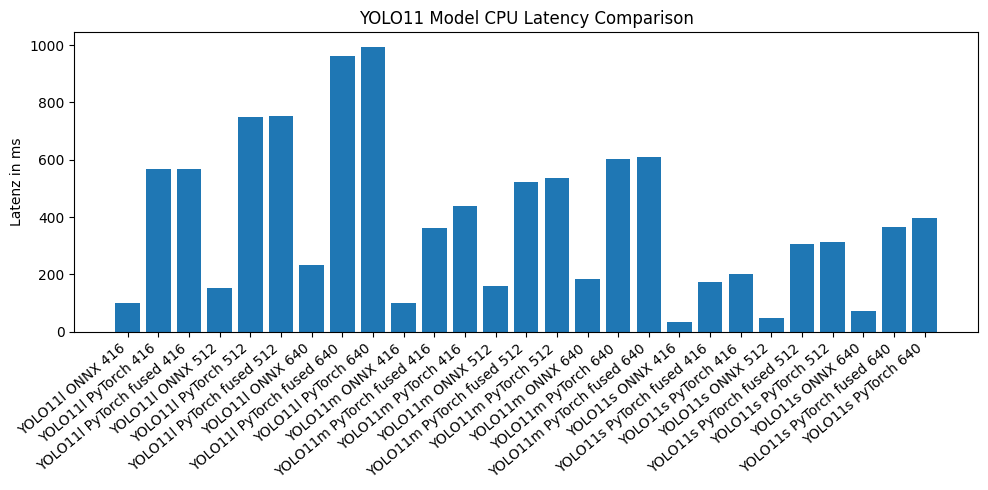

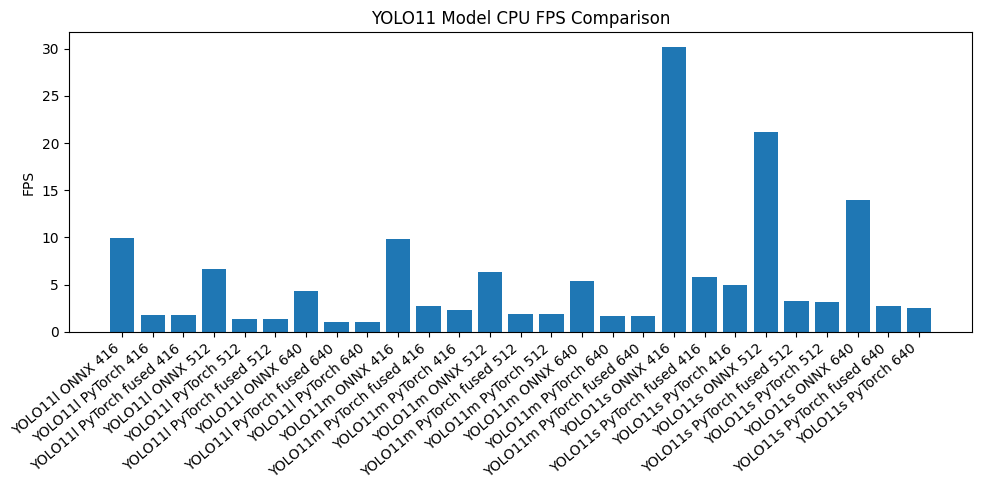

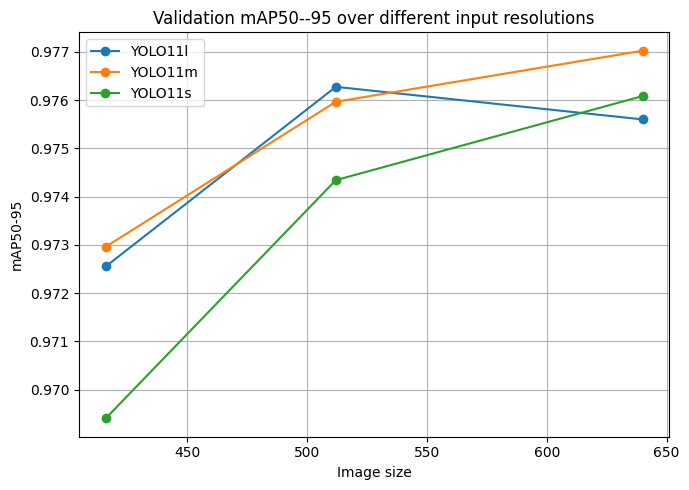

In [26]:
import matplotlib.pyplot as plt

# Speed: results_df
if not results_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(results_df["variant"], results_df["latency_ms"])
    plt.xticks(rotation=40, ha="right")
    plt.ylabel("Latenz in ms")
    plt.title("YOLO11 Model CPU Latency Comparison")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(results_df["variant"], results_df["fps"])
    plt.xticks(rotation=40, ha="right")
    plt.ylabel("FPS")
    plt.title("YOLO11 Model CPU FPS Comparison")
    plt.tight_layout()
    plt.show()
else:
    print("Keine Speed Ergebnisse vorhanden.")

# Accuracy: mAP50-95 ueber Bildgroessen pro Modell
if not metrics_df.empty:
    plt.figure(figsize=(7, 5))
    for model_name in metrics_df["model"].unique():
        sub = metrics_df[metrics_df["model"] == model_name]
        plt.plot(sub["image_size"], sub["mAP50_95"], marker="o", label=model_name)
    plt.xlabel("Image size")
    plt.ylabel("mAP50-95")
    plt.title("Validation mAP50--95 over different input resolutions")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Keine Metrik Ergebnisse vorhanden.")


In [22]:
# Kombinierte Tabelle Speed + Accuracy
if not metrics_df.empty:
    full_df = pd.merge(
        results_df,
        metrics_df,
        on=["model", "image_size"],
        how="left",
    )
else:
    full_df = results_df.copy()

results_df.to_csv("yolo11_speed_results.csv", index=False)
metrics_df.to_csv("yolo11_accuracy_results.csv", index=False)
full_df.to_csv("yolo11_full_results.csv", index=False)

full_df.head()


,model,variant,backend,fused,image_size,latency_ms,fps,mAP50,mAP50_95,precision,recall
0,YOLO11l,YOLO11l ONNX 416,onnxruntime,None,416,100.784596,9.922151,0.994727,0.972552,0.997341,0.997859
1,YOLO11l,YOLO11l PyTorch 416,pytorch,False,416,568.033066,1.760461,0.994727,0.972552,0.997341,0.997859
2,YOLO11l,YOLO11l PyTorch fused 416,pytorch,True,416,568.506362,1.758995,0.994727,0.972552,0.997341,0.997859
3,YOLO11l,YOLO11l ONNX 512,onnxruntime,None,512,151.170636,6.615041,0.994717,0.976274,0.997809,0.998356
4,YOLO11l,YOLO11l PyTorch 512,pytorch,False,512,750.745092,1.332010,0.994717,0.976274,0.997809,0.998356
